## Notebook Navigation


- [Top 10 Countries by Total Sales](#top-10-countries-by-total-sales)
- [Overall Monthly Sales Trend](#overall-monthly-sales-trend)
- [New Customers by Month](#new-customers-by-month)
- [Purchases by Day and Hour](#purchases-by-day-and-hour)
- [Top 10 Best-Selling Products Overall](#top-10-best-selling-products-overall)
- [Best-Selling Product by Country](#best-selling-product-by-country)
- [Top 10 Largest Orders and When They Were Made](#top-10-largest-orders-and-when-they-were-made)
- [Top 10 Customers by Total Sales](#top-10-customers-by-total-sales)
- [Sales vs Returns/Cancellations Impact](#sales-vs-returns-cancellations-impact)

># Import_Libraries

In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

plt.rcParams['figure.figsize'] = (20, 5) # to make sure all charts are automatically generated at (20,7), because i am blind

In [91]:
df = pd.read_csv("Online_Retail_clean2.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534130 entries, 0 to 534129
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   InvoiceNo                 534130 non-null  object 
 1   StockCode                 534130 non-null  object 
 2   Description               534130 non-null  object 
 3   Quantity                  534130 non-null  int64  
 4   InvoiceDate               534130 non-null  object 
 5   UnitPrice                 534130 non-null  float64
 6   CustomerID                401564 non-null  float64
 7   Country                   534130 non-null  object 
 8   Missing_Description_Flag  534130 non-null  bool   
 9   Cancelled_Order_Flag      534130 non-null  bool   
 10  CustomerID_Label          534130 non-null  object 
dtypes: bool(2), float64(2), int64(1), object(6)
memory usage: 37.7+ MB


In [92]:
# Even though we checked for and deleted duplicates, we will check again on this data.csv
df.duplicated().sum()

0

In [93]:
# Show only columns with missing values
null_counts = df.isnull().sum()

null_counts[null_counts > 0]

CustomerID    132566
dtype: int64

### CustomerID Missing Values

The `CustomerID` column still contains missing values. However, these rows were kept because they still include useful sales information such as invoice number, product description, quantity, invoice date, unit price, and country.

For analysis, the original `CustomerID` column will not be used directly. Instead, the cleaned `CustomerID_Label` column will be used. Missing customer IDs were labelled as `Unknown Customer`, which allows the records to remain in the dataset without losing valid sales data.

># InvoiceDate_to_datetime

In [94]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    format='%m/%d/%Y %H:%M'
)

display(df['InvoiceDate'].dtype)

dtype('<M8[ns]')

In [95]:
# Extract only the calendar date from InvoiceDate
df['InvoiceDate_Day'] = df['InvoiceDate'].dt.date

# Extract only the time portion from InvoiceDate
df['InvoiceDate_Time'] = df['InvoiceDate'].dt.time

# Extract the year from InvoiceDate
df['InvoiceYear'] = df['InvoiceDate'].dt.year

# Extract the month number from InvoiceDate
df['InvoiceMonth'] = df['InvoiceDate'].dt.month

# Extract the day name from InvoiceDate, such as Monday, Tuesday, etc.
df['InvoiceDayName'] = df['InvoiceDate'].dt.day_name()

# Extract the hour from InvoiceDate to analyze purchase time during the day
df['InvoiceHour'] = df['InvoiceDate'].dt.hour

# Extract year and month together for monthly trend analysis
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

df[
    ['InvoiceDate', 'InvoiceDate_Day', 'InvoiceDate_Time',
     'InvoiceYear', 'InvoiceMonth', 'InvoiceDayName',
     'InvoiceHour', 'YearMonth']
].head()

,InvoiceDate,InvoiceDate_Day,InvoiceDate_Time,InvoiceYear,InvoiceMonth,InvoiceDayName,InvoiceHour,YearMonth
0,2010-12-01 08:26:00,2010-12-01,08:26:00,2010,12,Wednesday,8,2010-12
1,2010-12-01 08:26:00,2010-12-01,08:26:00,2010,12,Wednesday,8,2010-12
2,2010-12-01 08:26:00,2010-12-01,08:26:00,2010,12,Wednesday,8,2010-12
3,2010-12-01 08:26:00,2010-12-01,08:26:00,2010,12,Wednesday,8,2010-12
4,2010-12-01 08:26:00,2010-12-01,08:26:00,2010,12,Wednesday,8,2010-12


In [96]:
# Create time of day category for easy manipulation/exploration
def time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Invoice_Time_of_Day'] = df['InvoiceHour'].apply(time_of_day)

### Invoice_Time_of_Day Review

The `Invoice_Time_of_Day` column was created from the invoice hour to group transactions into broader parts of the day: Morning, Afternoon, Evening, and Night.

This feature helps analyze when orders are most commonly recorded and will be useful for order timing analysis, especially when reviewing large orders.

The results show that most transactions occurred in the afternoon, followed by morning and evening. No night transactions appeared in the dataset, suggesting that orders were mainly recorded during regular business hours.

In [97]:
df[
    ['InvoiceDate', 'InvoiceDate_Day', 'InvoiceDate_Time',
     'InvoiceYear', 'InvoiceMonth', 'InvoiceDayName',
     'InvoiceHour', 'YearMonth', "Invoice_Time_of_Day"]
].isnull().sum()

InvoiceDate            0
InvoiceDate_Day        0
InvoiceDate_Time       0
InvoiceYear            0
InvoiceMonth           0
InvoiceDayName         0
InvoiceHour            0
YearMonth              0
Invoice_Time_of_Day    0
dtype: int64

In [98]:
df['Invoice_Time_of_Day'].value_counts()

Invoice_Time_of_Day
Afternoon    344904
Morning      148741
Evening       40485
Name: count, dtype: int64

<li>InvoiceDate was converted from string/object format to datetime format.
<li>This allows us to extract date-based features for trend analysis, such as year, month, day name, hour, and year-month.

In [99]:
df['CustomerID_Label'].value_counts()

CustomerID_Label
Unknown Customer    132566
17841                 7812
14911                 5896
14096                 5128
12748                 4458
                     ...  
13703                    1
16579                    1
16148                    1
17102                    1
14679                    1
Name: count, Length: 4372, dtype: int64

### CustomerID_Label Review

The `CustomerID_Label` column was created to support customer-level analysis while preserving rows with missing customer IDs.

Rows with missing `CustomerID` values were labelled as `Unknown Customer`. This allows the records to remain available for sales, product, country, and time-based analysis.

However, for customer-specific charts such as Top Customers, `Unknown Customer` will be excluded because it represents missing customer information rather than a real individual customer.

># Total_Sales column

In [100]:
df['Total_Sales'] = round(df['Quantity'] * df['UnitPrice'], 2) # rounded off to 2 decimal points
df['Total_Sales'].describe()

count    534130.000000
mean         18.229774
std         381.246602
min     -168469.600000
25%           3.750000
50%           9.900000
75%          17.570000
max      168469.600000
Name: Total_Sales, dtype: float64

The `Total_Sales` column was created by multiplying `Quantity` by `UnitPrice`.

`Total_Sales` can be positive or negative:
- Positive values represent sales transactions.
- Negative values likely represent returns or cancelled orders.
- Large matching positive and negative values may indicate a sale and its related cancellation.

This column will be used as the main sales value for revenue, product, country, customer, and order-level analysis.

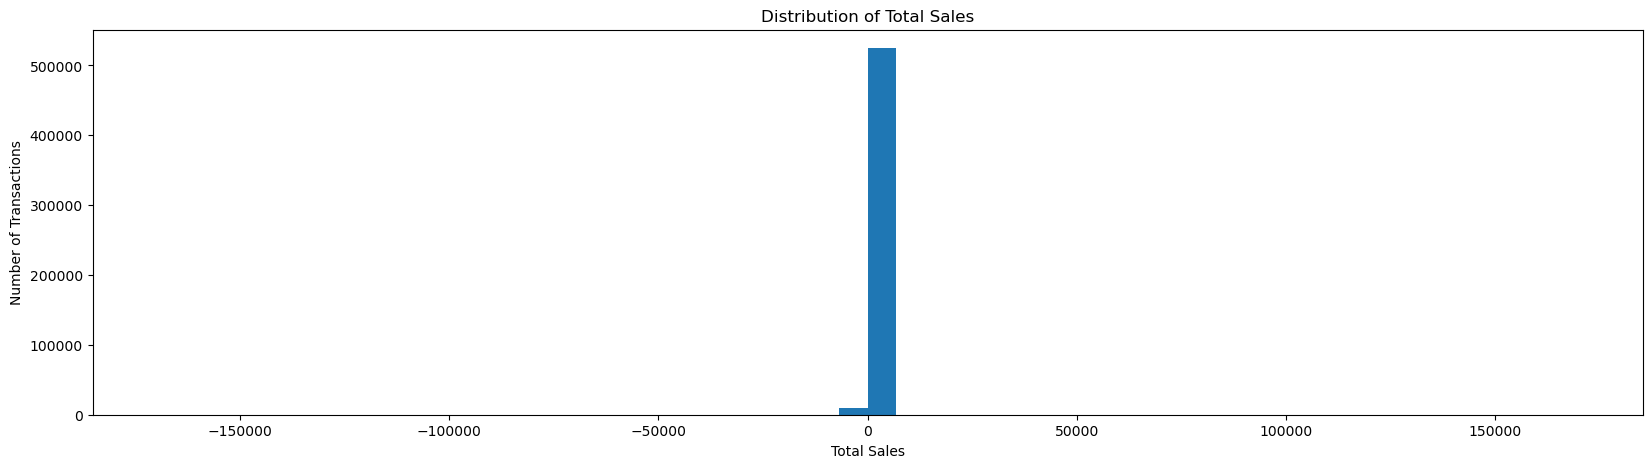

In [101]:
plt.hist(df['Total_Sales'], bins=50)

plt.title('Distribution of Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Number of Transactions')
plt.show()

The full histogram of `Total_Sales` is heavily affected by extreme positive and negative outliers. 
Therefore, a zoomed-in histogram was created to better show the distribution of typical transaction values.

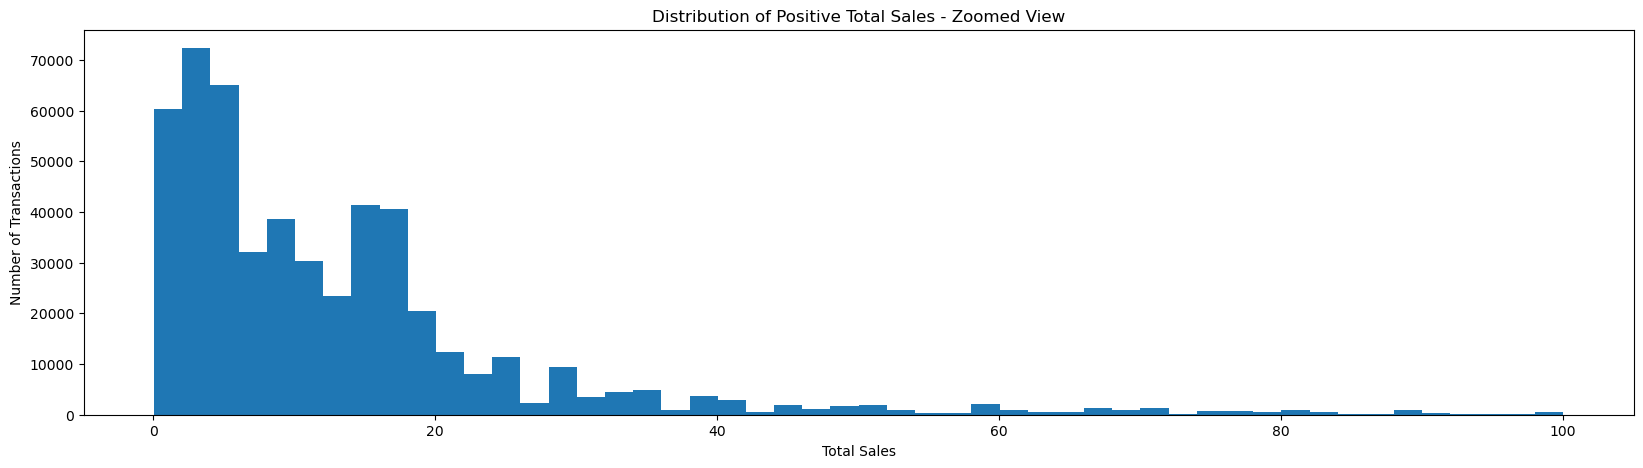

In [102]:
# Histogram of positive Total_Sales values under 100
plt.hist(
    df[(df['Total_Sales'] > 0) & (df['Total_Sales'] <= 100)]['Total_Sales'],
    bins=50
)

plt.title('Distribution of Positive Total Sales - Zoomed View')
plt.xlabel('Total Sales')
plt.ylabel('Number of Transactions')
plt.show()

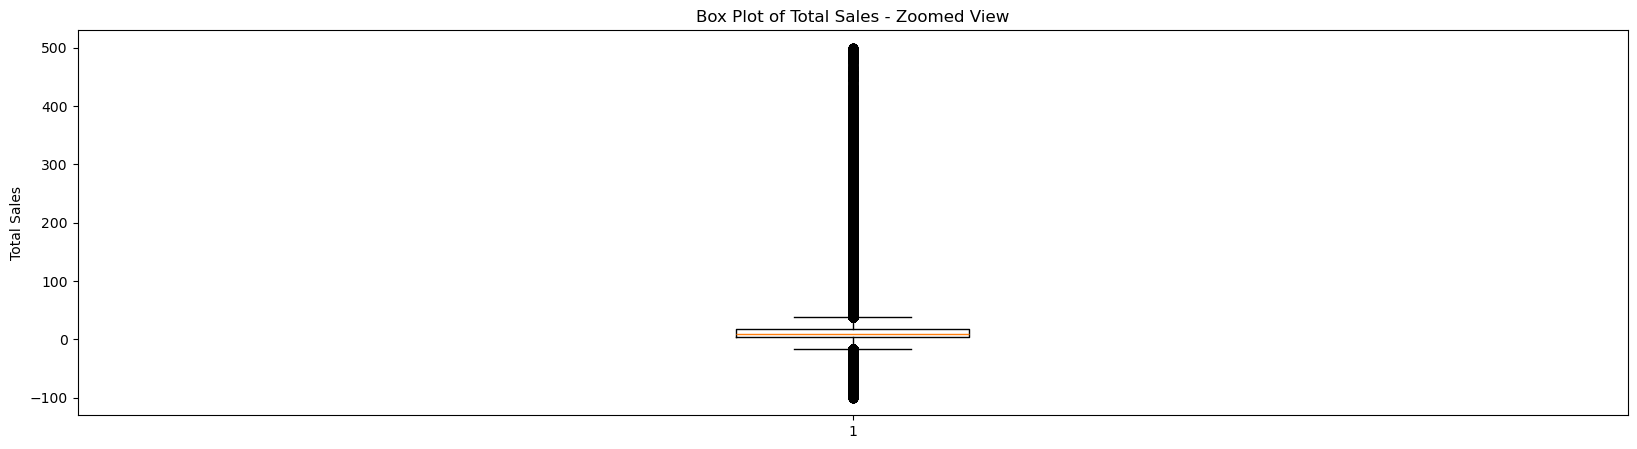

In [103]:
# Zoomed-in box plot for typical Total_Sales values
total_sales_zoom = df[(df['Total_Sales'] >= -100) & (df['Total_Sales'] <= 500)]['Total_Sales']

plt.boxplot(total_sales_zoom)

plt.title('Box Plot of Total Sales - Zoomed View')
plt.ylabel('Total Sales')
plt.show()

A box plot was created to review the spread of transaction values and identify outliers.

The full box plot is affected by very large positive and negative values. These extreme values likely represent large orders, returns, or cancellations. A zoomed-in box plot was also created to better show the distribution of typical transaction values.

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534130 entries, 0 to 534129
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   InvoiceNo                 534130 non-null  object        
 1   StockCode                 534130 non-null  object        
 2   Description               534130 non-null  object        
 3   Quantity                  534130 non-null  int64         
 4   InvoiceDate               534130 non-null  datetime64[ns]
 5   UnitPrice                 534130 non-null  float64       
 6   CustomerID                401564 non-null  float64       
 7   Country                   534130 non-null  object        
 8   Missing_Description_Flag  534130 non-null  bool          
 9   Cancelled_Order_Flag      534130 non-null  bool          
 10  CustomerID_Label          534130 non-null  object        
 11  InvoiceDate_Day           534130 non-null  object        
 12  In

># Investigation-Exploration-Visualization

<a id="top-10-countries-by-total-sales"></a>

## 1. Top 10 Countries by Total Sales

This chart shows the top 10 countries based on total sales value.

Sales were grouped by country and summed using the `Total_Sales` column. Since `Total_Sales` includes both positive and negative transaction values, the result represents net sales after accounting for returns or cancellations.

A horizontal bar chart was used because it makes the country names easier to read and allows quick comparison between countries.

In [105]:
# Group total sales by country
sales_by_country = (
    df.groupby('Country')['Total_Sales']
    .sum()
    .sort_values(ascending=False)
)

# Convert the top 10 countries into a dataframe
top_10_countries = sales_by_country.head(10).reset_index()

# Rename columns for clarity
top_10_countries.columns = ['Country', 'Total_Sales']

top_10_countries

,Country,Total_Sales
0,United Kingdom,8178190.24
1,Netherlands,284661.54
2,EIRE,262993.38
3,Germany,221509.47
4,France,197317.11
5,Australia,137009.77
6,Switzerland,56363.05
7,Spain,54756.03
8,Belgium,40910.96
9,Sweden,36585.41


In [106]:
# Convert the top 10 sales by country into a dataframe
top_10_countries = sales_by_country.head(10).reset_index()

# Rename columns for clarity
top_10_countries.columns = ['Country', 'Total_Sales']

top_10_countries


# Create a horizontal bar chart using Plotly Express
fig = px.bar(
    top_10_countries.sort_values('Total_Sales'),  # Sort values so largest bar appears at the top after horizontal plotting
    x='Total_Sales',                              # Total sales shown on the x-axis
    y='Country',                                  # Countries shown on the y-axis
    orientation='h',                              # Horizontal bar chart
    title='Top 10 Countries by Total Sales',      # Chart title
    text='Total_Sales'                            # Display total sales value on each bar
)

# Format the text labels on the bars
fig.update_traces(
    texttemplate='%{text:,.2f}',  # Format sales values with commas and 2 decimal places
    textposition='outside'        # Place labels outside the bars
)

# Update chart layout and axis labels
fig.update_layout(
    xaxis_title='Total Sales',  # Label for x-axis
    yaxis_title='Country',      # Label for y-axis
    height=600                  # Set chart height
)

# Display the chart
fig.show()

<a id="overall-monthly-sales-trend"></a>

## 2. Overall Monthly Sales Trend

This line chart shows the total sales trend by month.

Sales were grouped by `YearMonth` and summed using the `Total_Sales` column. Since `Total_Sales` includes both positive and negative values, the monthly totals represent net sales after accounting for returns or cancellations.

The chart also includes an interactive hover feature showing the top 3 countries contributing to sales in each month. This helps identify whether monthly sales performance was driven by one country or spread across multiple countries.

A line chart was used because monthly sales are time-based, and a line chart makes it easier to see trends, peaks, and declines over time.

In [107]:
# Group total sales by YearMonth
# This gives the overall monthly sales trend
monthly_sales = (
    df.groupby('YearMonth')['Total_Sales']
    .sum()
    .reset_index()
)

# Convert YearMonth to string so Plotly displays it nicely on the x-axis
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

# Display the first few rows
monthly_sales.head()

,YearMonth,Total_Sales
0,2010-12,746723.61
1,2011-01,558448.56
2,2011-02,497026.41
3,2011-03,682013.98
4,2011-04,492367.84


In [108]:
# Group sales by both YearMonth and Country
# This lets us see which countries contributed the most sales each month
monthly_country_sales = (
    df.groupby(['YearMonth', 'Country'])['Total_Sales']
    .sum()
    .reset_index()
)

# Convert YearMonth to string so it can match the monthly_sales dataframe
monthly_country_sales['YearMonth'] = monthly_country_sales['YearMonth'].astype(str)

# Sort by month and sales amount
# Highest sales country will appear first within each month
monthly_country_sales = monthly_country_sales.sort_values(
    ['YearMonth', 'Total_Sales'],
    ascending=[True, False]
)

# Select the top 3 countries for each month
top_3_countries_monthly = monthly_country_sales.groupby('YearMonth').head(3)

# Display first few rows
top_3_countries_monthly.head(10)

,YearMonth,Country,Total_Sales
23,2010-12,United Kingdom,674615.86
10,2010-12,Germany,14527.44
9,2010-12,France,9575.36
47,2011-01,United Kingdom,432995.40
40,2011-01,Netherlands,26611.16
29,2011-01,EIRE,21656.52
71,2011-02,United Kingdom,407256.67
62,2011-02,Netherlands,22932.11
48,2011-02,Australia,14627.47
95,2011-03,United Kingdom,558458.89


In [109]:
# Create readable hover text showing the top 3 countries for each month
# Create readable hover text with comma-formatted sales values
top_3_hover = (
    top_3_countries_monthly
    .groupby('YearMonth')
    .apply(
        lambda x: '<br>'.join(
            x['Country'] + ': ' + x['Total_Sales'].map('{:,.2f}'.format)
        )
    )
    .reset_index(name='Top_3_Countries')
)

# Display first few rows
top_3_hover.head()

C:\Users\azimi\AppData\Local\Temp\ipykernel_26068\2488154115.py:6: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,YearMonth,Top_3_Countries
0,2010-12,"United Kingdom: 674,615.86<br>Germany: 14,527...."
1,2011-01,"United Kingdom: 432,995.40<br>Netherlands: 26,..."
2,2011-02,"United Kingdom: 407,256.67<br>Netherlands: 22,..."
3,2011-03,"United Kingdom: 558,458.89<br>Netherlands: 22,..."
4,2011-04,"United Kingdom: 441,414.76<br>Germany: 11,963...."


In [110]:
# Merge overall monthly sales with the top 3 country information
# This prepares the final dataframe for the Plotly line chart
monthly_sales_plotly = monthly_sales.merge(
    top_3_hover,
    on='YearMonth',
    how='left'
)

# Display first few rows
monthly_sales_plotly.head()

,YearMonth,Total_Sales,Top_3_Countries
0,2010-12,746723.61,"United Kingdom: 674,615.86<br>Germany: 14,527...."
1,2011-01,558448.56,"United Kingdom: 432,995.40<br>Netherlands: 26,..."
2,2011-02,497026.41,"United Kingdom: 407,256.67<br>Netherlands: 22,..."
3,2011-03,682013.98,"United Kingdom: 558,458.89<br>Netherlands: 22,..."
4,2011-04,492367.84,"United Kingdom: 441,414.76<br>Germany: 11,963...."


In [111]:
# Create an interactive line chart for monthly sales trend
fig = px.line(
    monthly_sales_plotly,                     # Dataframe used for the chart
    x='YearMonth',                            # Month shown on the x-axis
    y='Total_Sales',                          # Total monthly sales shown on the y-axis
    markers=True,                             # Add markers to each monthly point
    title='Overall Monthly Sales Trend',      # Chart title
    custom_data=['Top_3_Countries']           # Extra data to show in hover tooltip
)

# Customize the hover tooltip
fig.update_traces(
    hovertemplate=
    '<b>Month:</b> %{x}<br>' +
    '<b>Total Sales:</b> %{y:,.2f}<br><br>' +
    '<b>Top 3 Countries:</b><br>%{customdata[0]}<extra></extra>'
)

# Update chart layout and axis labels
fig.update_layout(
    xaxis_title='Month',        # Label for x-axis
    yaxis_title='Total Sales',  # Label for y-axis
    height=600                  # Set chart height
)

# Display the chart
fig.show()

<a id="new-customers-by-month"></a>

## 3. New Customers by Month

This chart compares new and returning customers for each month.

A set comparison was used to identify new customers. For each month, the customers in that month were compared against all customers seen in previous months. Customers who had not appeared before were counted as new customers, while customers already seen in earlier months were counted as returning customers.

The first month was excluded from the chart because all customers in the first month are counted as new by default. A grouped bar chart was used because it clearly compares new and returning customers side by side for each month.

Since Unknown Customer is not a real customer, we should exclude it.

In [112]:
# Create dataframe with known customers only
# Unknown Customer is excluded because it does not represent a real identifiable customer
df_known_customers = df[df['CustomerID_Label'] != 'Unknown Customer'].copy()

# Sort data by YearMonth so the customer history builds in the correct order
df_known_customers = df_known_customers.sort_values('YearMonth')

# Create an empty set to store all customers seen in previous months
previous_customers = set()

# Create an empty list to store the monthly results
new_customer_results = []

# Loop through each month in chronological order
for month in sorted(df_known_customers['YearMonth'].unique()):
    
    # Get the unique customers who purchased in the current month
    current_month_customers = set(
        df_known_customers[df_known_customers['YearMonth'] == month]['CustomerID_Label']
    )
    
    # New customers are customers in the current month who were not seen before
    new_customers = current_month_customers - previous_customers
    
    # Store the results for this month
    new_customer_results.append({
        'YearMonth': month,
        'Total_Customers_This_Month': len(current_month_customers),
        'New_Customers': len(new_customers),
        'Returning_Customers': len(current_month_customers) - len(new_customers)
    })
    
    # Add current month customers to the previous customer history
    previous_customers.update(current_month_customers)

# Convert results into a dataframe
new_customers_df = pd.DataFrame(new_customer_results)

# Convert YearMonth to string for cleaner display and plotting
new_customers_df['YearMonth'] = new_customers_df['YearMonth'].astype(str)

# Display the result
new_customers_df

,YearMonth,Total_Customers_This_Month,New_Customers,Returning_Customers
0,2010-12,948,948,0
1,2011-01,783,421,362
2,2011-02,798,380,418
3,2011-03,1020,440,580
4,2011-04,899,299,600
5,2011-05,1079,279,800
6,2011-06,1051,235,816
7,2011-07,993,191,802
8,2011-08,980,167,813
9,2011-09,1302,298,1004


In [113]:
# Remove the first month from the chart
# The first month is excluded because all known customers in the first month are counted as new by default
new_customers_chart_df = new_customers_df.iloc[1:].copy()

# Convert the dataframe from wide format to long format
# Plotly Express works better for grouped bar charts in long format
new_customers_long = new_customers_chart_df.melt(
    id_vars='YearMonth',                              # Keep YearMonth as the x-axis category
    value_vars=['New_Customers', 'Returning_Customers'], # These columns become bar categories
    var_name='Customer_Type',                         # New column showing New vs Returning
    value_name='Customer_Count'                       # New column showing the count
)

# Display the reshaped dataframe
new_customers_long.head()

,YearMonth,Customer_Type,Customer_Count
0,2011-01,New_Customers,421
1,2011-02,New_Customers,380
2,2011-03,New_Customers,440
3,2011-04,New_Customers,299
4,2011-05,New_Customers,279


In [114]:
# Create a grouped bar chart comparing new and returning customers by month
fig = px.bar(
    new_customers_long,                          # Dataframe used for the chart
    x='YearMonth',                               # Month shown on x-axis
    y='Customer_Count',                          # Customer count shown on y-axis
    color='Customer_Type',                       # Separate bars for New and Returning customers
    barmode='group',                             # Group bars side by side instead of stacking
    title='New vs Returning Customers by Month', # Chart title
    text='Customer_Count'                        # Show count labels on bars
)

# Format the labels on the bars
fig.update_traces(
    texttemplate='%{text:,}',  # Format counts with commas
    textposition='outside'     # Place labels outside the bars
)

# Update chart layout and axis labels
fig.update_layout(
    xaxis_title='Month',              # Label for x-axis
    yaxis_title='Number of Customers',# Label for y-axis
    legend_title='Customer Type',     # Legend title
    height=600                        # Set chart height
)

# Display the chart
fig.show()

<a id="purchases-by-day-and-hour"></a>

## 4. Purchases by Day and Hour

Day of the Week.

This bar chart shows the number of transactions recorded on each day of the week.

The days were ordered from Monday to Sunday to make the pattern easier to read. A bar chart was used because we are comparing transaction counts across weekday categories.

This helps identify which days had the highest and lowest purchasing activity.

In [115]:
# Define the correct order for days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Count number of transactions for each day of the week
orders_by_day = df['InvoiceDayName'].value_counts()

# Reorder the results so days appear Monday to Sunday
orders_by_day = orders_by_day.reindex(day_order)

# Display the result
orders_by_day

InvoiceDayName
Monday        94080.0
Tuesday      100468.0
Wednesday     93195.0
Thursday     102561.0
Friday        81025.0
Saturday          NaN
Sunday        62801.0
Name: count, dtype: float64

posx and posy should be finite values
posx and posy should be finite values


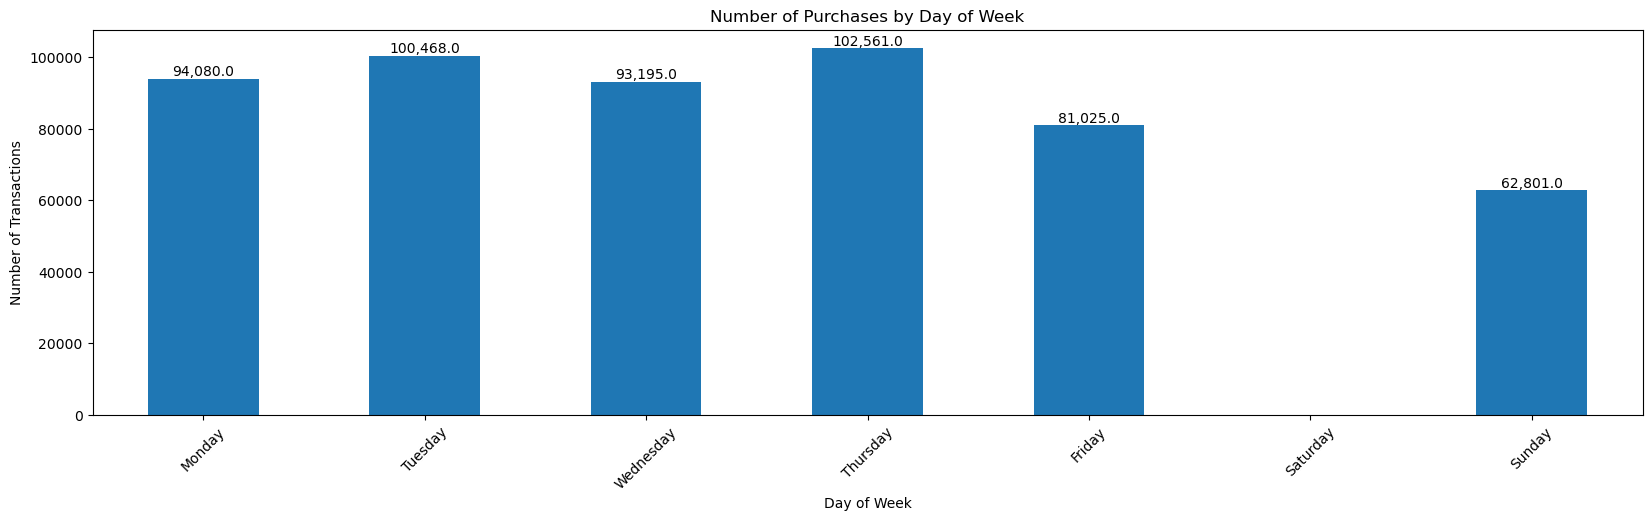

In [116]:
# Create a bar chart showing number of purchases by day of week
ax = orders_by_day.plot(kind='bar')

# Add chart title and axis labels
plt.title('Number of Purchases by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add transaction count labels above each bar
for index, value in enumerate(orders_by_day):
    plt.text(
        index,              # x-position of label
        value,              # y-position of label
        f'{value:,}',        # format number with comma
        ha='center',         # center align text
        va='bottom'          # place text above bar
    )

# Display the chart
plt.show()

Hour of Day/ Time of day

This bar chart shows the number of transactions recorded during each hour of the day.

The invoice hour was used to count how many purchases occurred at each hour. The results help identify the busiest transaction periods during the day.

A bar chart was used because the analysis compares transaction counts across hourly time categories.

In [117]:
# Count the number of transactions for each invoice hour
orders_by_hour = df['InvoiceHour'].value_counts().sort_index()

# Display the transaction count by hour
orders_by_hour

InvoiceHour
6        41
7       383
8      8899
9     34208
10    48602
11    56608
12    77322
13    71052
14    66066
15    76558
16    53906
17    28136
18     7886
19     3616
20      847
Name: count, dtype: int64

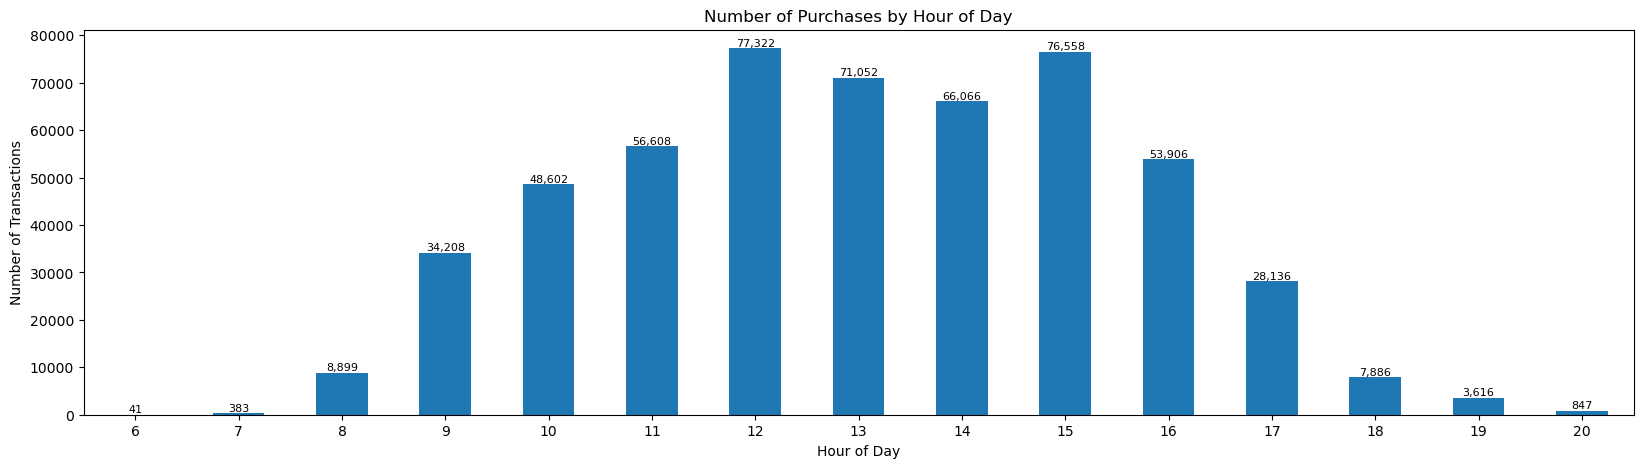

In [118]:
# Create a bar chart showing number of purchases by hour of day
ax = orders_by_hour.plot(kind='bar')

# Add chart title and axis labels
plt.title('Number of Purchases by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')

# Keep x-axis labels horizontal because hour numbers are short
plt.xticks(rotation=0)

# Add transaction count labels above each bar
for index, value in enumerate(orders_by_hour):
    plt.text(
        index,              # x-position of label
        value,              # y-position of label
        f'{value:,}',        # format number with comma
        ha='center',         # center align text
        va='bottom',         # place text above bar
        fontsize=8           # smaller font so labels do not crowd too much
    )

# Display the chart
plt.show()

In [119]:
# Check which invoice hours appear in the dataset
df['InvoiceHour'].min(), df['InvoiceHour'].max()

(6, 20)

The invoice hour ranges from 6 AM to 8 PM. This confirms that transactions were mainly recorded during daytime and evening hours, with no late-night transaction records in the dataset.

In [120]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Missing_Description_Flag',
       'Cancelled_Order_Flag', 'CustomerID_Label', 'InvoiceDate_Day',
       'InvoiceDate_Time', 'InvoiceYear', 'InvoiceMonth', 'InvoiceDayName',
       'InvoiceHour', 'YearMonth', 'Invoice_Time_of_Day', 'Total_Sales'],
      dtype='object')

Time of Day

This bar chart shows the number of transactions grouped by time of day.

The `Invoice_Time_of_Day` column was created from the invoice hour and groups purchases into Morning, Afternoon, Evening, and Night. The categories were ordered logically to make the pattern easier to understand.

This chart helps summarize purchasing activity into broader daily periods instead of showing each individual hour.

In [121]:
# Define the correct order for time-of-day categories
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']

# Count the number of transactions for each time-of-day category
orders_by_TOD = df['Invoice_Time_of_Day'].value_counts()

# Reorder the results into a logical time sequence
orders_by_TOD = orders_by_TOD.reindex(time_order)

# Remove categories that do not appear in the dataset
# In this dataset, Night may not appear because InvoiceHour ranges from 6 to 20
orders_by_TOD = orders_by_TOD.dropna()

# Display the transaction count by time of day
orders_by_TOD

Invoice_Time_of_Day
Morning      148741.0
Afternoon    344904.0
Evening       40485.0
Name: count, dtype: float64

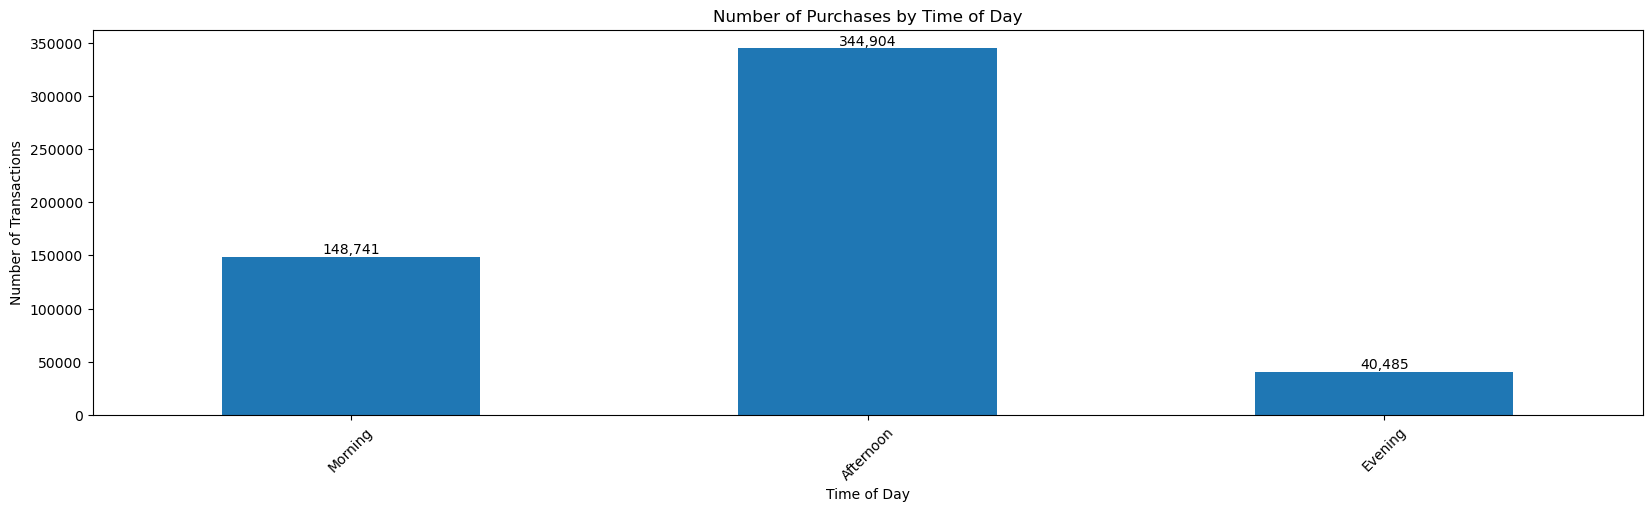

In [122]:
# Create a bar chart showing number of purchases by time of day
ax = orders_by_TOD.plot(kind='bar')

# Add chart title and axis labels
plt.title('Number of Purchases by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Number of Transactions')

# Rotate x-axis labels slightly for readability
plt.xticks(rotation=45)

# Add transaction count labels above each bar
for index, value in enumerate(orders_by_TOD):
    plt.text(
        index,              # x-position of label
        value,              # y-position of label
        f'{int(value):,}',   # format count with comma and no decimals
        ha='center',         # center align text
        va='bottom'          # place text above bar
    )

# Display the chart
plt.show()

<a id="top-10-best-selling-products-overall"></a>

## 5. Top 10 Best-Selling Products Overall

Best Product Sold by Quantity (without returns)


This chart shows the top 10 products based on total quantity sold.

Only positive quantity records were used for this analysis so that returns or cancellations do not reduce the product sales count. The products were grouped by description, and the total quantity sold was calculated for each product.

A horizontal bar chart was used because product descriptions are long and easier to read on the y-axis.

In [123]:
# Create a sales-only dataframe by keeping rows with positive Quantity
# This avoids returns/cancellations reducing the quantity sold
df_positive_quantity = df[df['Quantity'] > 0].copy()

# Group by product description and calculate total quantity sold
top_products = (
    df_positive_quantity.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

# Convert the top 10 products into a dataframe for easier plotting
top_10_products_quantity = top_products.head(10).reset_index()

# Rename columns for clarity
top_10_products_quantity.columns = ['Product', 'Quantity_Sold']

# Display the top 10 products by quantity sold
top_10_products_quantity

,Product,Quantity_Sold
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,78033
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
3,JUMBO BAG RED RETROSPOT,48371
4,WHITE HANGING HEART T-LIGHT HOLDER,37872
5,POPCORN HOLDER,36749
6,PACK OF 72 RETROSPOT CAKE CASES,36396
7,ASSORTED COLOUR BIRD ORNAMENT,36362
8,RABBIT NIGHT LIGHT,30739
9,MINI PAINT SET VINTAGE,26633


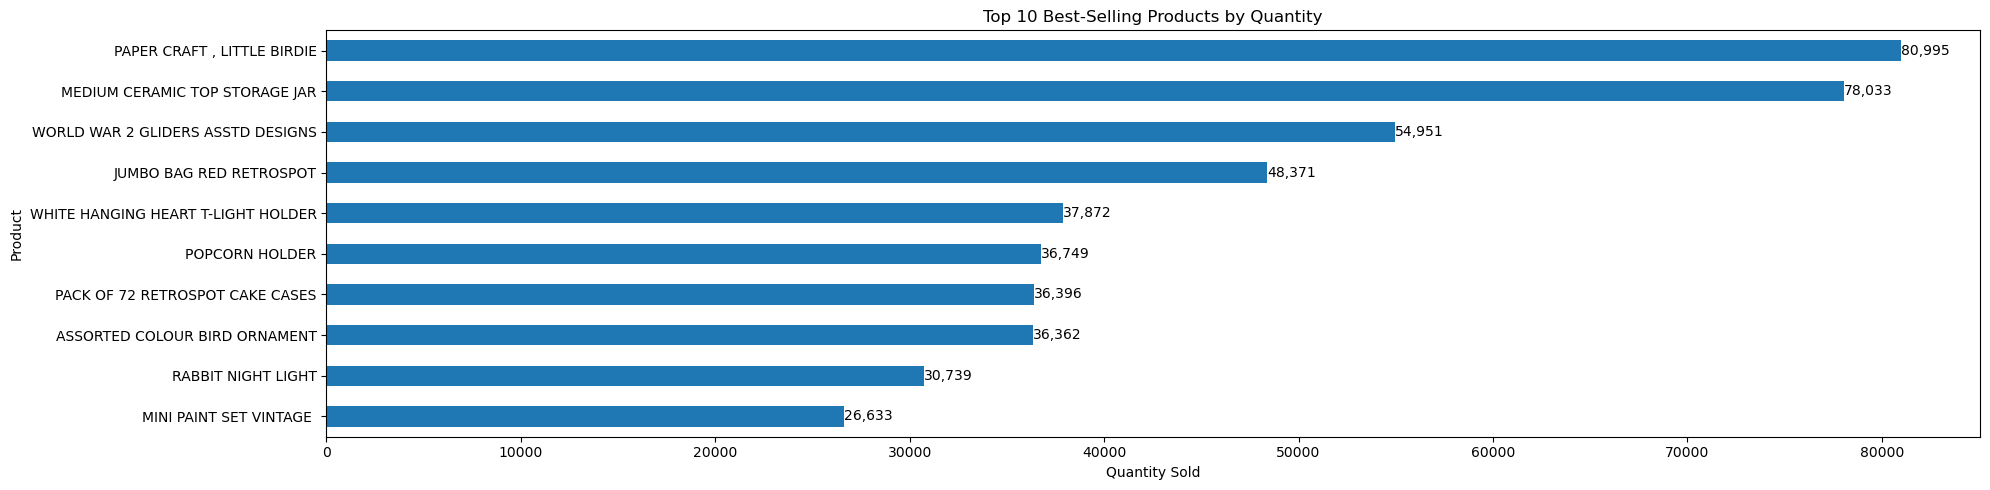

In [124]:
# Create a horizontal bar chart for top 10 products by quantity sold
ax = top_10_products_quantity.sort_values('Quantity_Sold').plot(
    kind='barh',
    x='Product',
    y='Quantity_Sold',
    legend=False
)

# Add chart title and axis labels
plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')

# Add quantity labels beside each bar
for index, value in enumerate(top_10_products_quantity.sort_values('Quantity_Sold')['Quantity_Sold']):
    plt.text(
        value,              # x-position of label
        index,              # y-position of label
        f'{int(value):,}',   # format quantity with commas
        va='center'          # vertically center label beside bar
    )

# Adjust layout so long product names fit properly
plt.tight_layout()

# Display the chart
plt.show()

<a id="best-selling-product-by-country"></a>

## 6. Best-Selling Product by Country

This chart shows the top 10 country-product combinations based on quantity sold.

The analysis first grouped the data by `Country` and `Description`, then calculated the total quantity sold for each product within each country. The highest-selling product was selected for each country, and the top 10 results were displayed.

Only positive quantity records were used so that returns or cancellations do not reduce the product sales count.

A horizontal Plotly bar chart was used because the country-product labels are long, and Plotly allows the full product details to be viewed clearly in the hover tooltip.

In [125]:
# Create a dataframe with only positive Quantity values
# This keeps the analysis focused on sold products and excludes returns/cancellations
df_positive_quantity = df[df['Quantity'] > 0].copy()

# Group by Country and Description, then calculate total quantity sold
product_sales_by_country = (
    df_positive_quantity
    .groupby(['Country', 'Description'])['Quantity']
    .sum()
    .reset_index()
)

# Sort by Country and Quantity
# This makes the highest-selling product appear first within each country
product_sales_by_country = product_sales_by_country.sort_values(
    ['Country', 'Quantity'],
    ascending=[True, False]
)

# Get the top-selling product for each country
best_product_each_country = (
    product_sales_by_country
    .groupby('Country')
    .head(1)
)

# From all countries, keep only the top 10 country-product combinations by quantity sold
best_product_top10 = (
    best_product_each_country
    .sort_values('Quantity', ascending=False)
    .head(10)
    .copy()
)

# Create a combined label for easier chart display
best_product_top10['Country_Product'] = (
    best_product_top10['Country'] + ' - ' + best_product_top10['Description']
)

# Display the final dataframe
best_product_top10

,Country,Description,Quantity,Country_Product
17972,United Kingdom,"PAPER CRAFT , LITTLE BIRDIE",80995,"United Kingdom - PAPER CRAFT , LITTLE BIRDIE"
10974,Netherlands,RABBIT NIGHT LIGHT,4801,Netherlands - RABBIT NIGHT LIGHT
6622,France,RABBIT NIGHT LIGHT,4024,France - RABBIT NIGHT LIGHT
10192,Japan,RABBIT NIGHT LIGHT,3408,Japan - RABBIT NIGHT LIGHT
287,Australia,MINI PAINT SET VINTAGE,2952,Australia - MINI PAINT SET VINTAGE
14238,Sweden,MINI PAINT SET VINTAGE,2916,Sweden - MINI PAINT SET VINTAGE
4282,EIRE,PACK OF 72 RETROSPOT CAKE CASES,1800,EIRE - PACK OF 72 RETROSPOT CAKE CASES
8432,Germany,ROUND SNACK BOXES SET OF4 WOODLAND,1221,Germany - ROUND SNACK BOXES SET OF4 WOODLAND
13200,Spain,CHILDRENS CUTLERY POLKADOT PINK,729,Spain - CHILDRENS CUTLERY POLKADOT PINK
15008,Switzerland,PLASTERS IN TIN WOODLAND ANIMALS,639,Switzerland - PLASTERS IN TIN WOODLAND ANIMALS


In [126]:
# Create an interactive horizontal bar chart
fig = px.bar(
    best_product_top10.sort_values('Quantity'),       # Sort so the largest bar appears at the top
    x='Quantity',                                     # Quantity sold on the x-axis
    y='Country_Product',                              # Country-product label on the y-axis
    orientation='h',                                  # Horizontal bar chart
    title='Top 10 Best-Selling Products by Country',  # Chart title
    text='Quantity',                                  # Show quantity value on each bar
    hover_data={
        'Country': True,                              # Show country in hover
        'Description': True,                          # Show product description in hover
        'Quantity': ':,'                              # Format quantity with commas
    }
)

# Format text labels on the bars
fig.update_traces(
    texttemplate='%{text:,}',  # Format quantity labels with commas
    textposition='outside'     # Place labels outside the bars
)

# Update chart layout and axis labels
fig.update_layout(
    xaxis_title='Quantity Sold',          # Label for x-axis
    yaxis_title='Country - Product',      # Label for y-axis
    height=700                            # Set chart height
)

# Display the chart
fig.show()

<a id="top-10-largest-orders-and-when-they-were-made"></a>

## 7. Top 10 Largest Orders and When They Were Made

This chart shows the top 10 largest orders based on total invoice value.

The data was grouped by `InvoiceNo` to calculate the total sales amount for each distinct order. Additional order details such as invoice date, day of week, hour, time of day, customer label, and country were included so that the timing and context of each large order could be reviewed.

A Plotly horizontal bar chart was used because it allows the largest orders to be compared clearly while also showing detailed information in the hover tooltip.

In [127]:
# Group transactions by invoice/order-level information
# This lets us calculate the total value of each distinct order
largest_orders = (
    df.groupby([
        'InvoiceNo',
        'InvoiceDate',
        'InvoiceDayName',
        'InvoiceHour',
        'Invoice_Time_of_Day',
        'CustomerID_Label',
        'Country'
    ])['Total_Sales']
    .sum()
    .reset_index()
)

# Sort orders from largest to smallest based on Total_Sales
largest_orders = largest_orders.sort_values('Total_Sales', ascending=False)

# Select the top 10 largest orders
top_10_largest_orders = largest_orders.head(10).copy()

# Display the result
top_10_largest_orders

,InvoiceNo,InvoiceDate,InvoiceDayName,InvoiceHour,Invoice_Time_of_Day,CustomerID_Label,Country,Total_Sales
19965,581483,2011-12-09 09:15:00,Friday,9,Morning,16446,United Kingdom,168469.60
2118,541431,2011-01-18 10:01:00,Tuesday,10,Morning,12346,United Kingdom,77183.60
16963,574941,2011-11-07 17:42:00,Monday,17,Evening,Unknown Customer,United Kingdom,52940.94
17620,576365,2011-11-14 17:55:00,Monday,17,Evening,Unknown Customer,United Kingdom,50653.91
8726,556444,2011-06-10 15:28:00,Friday,15,Afternoon,15098,United Kingdom,38970.00
13583,567423,2011-09-20 11:05:00,Tuesday,11,Morning,17450,United Kingdom,31698.16
8932,556917,2011-06-15 13:37:00,Wednesday,13,Afternoon,12415,Australia,22775.93
15732,572209,2011-10-21 12:08:00,Friday,12,Afternoon,18102,United Kingdom,22206.00
13575,567381,2011-09-20 10:12:00,Tuesday,10,Morning,17450,United Kingdom,22104.80
11918,563614,2011-08-18 08:51:00,Thursday,8,Morning,12415,Australia,21880.44


In [128]:
# Create a readable label for each invoice
# This will make the chart easier to understand
top_10_largest_orders['Invoice_Label'] = (
    'Invoice ' + top_10_largest_orders['InvoiceNo'].astype(str)
)

In [129]:
# Create an interactive horizontal bar chart for the top 10 largest orders
fig = px.bar(
    top_10_largest_orders.sort_values('Total_Sales'),  # Sort so largest order appears at the top
    x='Total_Sales',                                   # Order value shown on x-axis
    y='Invoice_Label',                                 # Invoice number shown on y-axis
    orientation='h',                                   # Horizontal bar chart
    title='Top 10 Largest Orders and When They Were Made',
    text='Total_Sales',                                # Show sales value on each bar
    hover_data={
        'InvoiceNo': True,                             # Show invoice number in hover
        'InvoiceDate': True,                           # Show full invoice date/time in hover
        'InvoiceDayName': True,                        # Show day of week in hover
        'InvoiceHour': True,                           # Show invoice hour in hover
        'Invoice_Time_of_Day': True,                   # Show morning/afternoon/evening in hover
        'CustomerID_Label': True,                      # Show customer label in hover
        'Country': True,                               # Show country in hover
        'Total_Sales': ':,.2f'                         # Format total sales with commas and 2 decimals
    }
)

# Format the text labels shown on the bars
fig.update_traces(
    texttemplate='%{text:,.2f}',  # Format sales values with commas and 2 decimals
    textposition='outside'        # Place labels outside the bars
)

# Update chart layout and axis labels
fig.update_layout(
    xaxis_title='Total Sales',    # Label for x-axis
    yaxis_title='Invoice Number', # Label for y-axis
    height=650                    # Set chart height
)

# Display the chart
fig.show()

<a id="top-10-customers-by-total-sales"></a>

## 8. Top 10 Customers by Total Sales

This chart shows the top 10 known customers based on total sales.

The analysis uses the `CustomerID_Label` column instead of the original `CustomerID` column. Records labelled as `Unknown Customer` were excluded because they represent missing customer IDs rather than an actual individual customer.

Sales were grouped by customer and summed using the `Total_Sales` column. A horizontal Plotly bar chart was used to make the customer rankings easy to compare and to provide clean hover information.

In [130]:
# Filter out Unknown Customer
# This keeps the customer analysis focused on known customers only
df_known_customers = df[df['CustomerID_Label'] != 'Unknown Customer'].copy()

# Group by CustomerID_Label and calculate total sales for each customer
top_customers = (
    df_known_customers.groupby('CustomerID_Label')['Total_Sales']
    .sum()
    .sort_values(ascending=False)
)

# Convert the top 10 customers into a dataframe
top_10_customers = top_customers.head(10).reset_index()

# Rename columns for clarity
top_10_customers.columns = ['CustomerID_Label', 'Total_Sales']

# Display the top 10 customers
top_10_customers

,CustomerID_Label,Total_Sales
0,14646,279489.02
1,18102,256438.49
2,17450,187322.17
3,14911,132458.73
4,12415,123725.45
5,14156,113214.59
6,17511,88125.38
7,16684,65892.08
8,13694,62690.54
9,15311,59284.19


In [131]:
# Create an interactive horizontal bar chart for top 10 customers
fig = px.bar(
    top_10_customers.sort_values('Total_Sales'),       # Sort so largest customer appears at the top
    x='Total_Sales',                                   # Total sales shown on x-axis
    y='CustomerID_Label',                              # Customer label shown on y-axis
    orientation='h',                                   # Horizontal bar chart
    title='Top 10 Customers by Total Sales (using CustomerID_Label: Unknown Label not included)',           # Chart title
    text='Total_Sales',                                # Show total sales value on each bar
    hover_data={
        'CustomerID_Label': True,                      # Show customer ID in hover
        'Total_Sales': ':,.2f'                         # Format total sales with commas and 2 decimals
    }
)

# Format the text labels on the bars
fig.update_traces(
    texttemplate='%{text:,.2f}',  # Format sales values with commas and 2 decimals
    textposition='outside'        # Place labels outside the bars
)

# Update chart layout and axis labels
fig.update_layout(
    xaxis_title='Total Sales',    # Label for x-axis
    yaxis_title='Customer ID',    # Label for y-axis
    height=600                    # Set chart height
)

# Display the chart
fig.show()

<a id="sales-vs-returns-cancellations-impact"></a>

## 9. Sales vs Returns/Cancellations Impact

This pie chart compares the overall magnitude of sales versus returns or cancellations.

Positive `Total_Sales` values were treated as sales, while negative `Total_Sales` values were treated as returns or cancellations. Since returns and cancellations appear as negative values, absolute values were used in the pie chart to show their proportional impact clearly.

This helps show how much returns or cancellations affect overall transaction value compared to regular sales.

In [132]:
# Create a transaction type column based on Total_Sales
# Positive values are treated as Sales
# Negative values are treated as Returns/Cancellations
df['Transaction_Type'] = df['Total_Sales'].apply(
    lambda x: 'Sales' if x >= 0 else 'Returns/Cancellations'
)

# Group total sales by transaction type
# This summarizes total positive sales and total negative returns/cancellations
sales_returns_summary = (
    df.groupby('Transaction_Type')['Total_Sales']
    .sum()
    .reset_index()
)

# Display the summary table
sales_returns_summary

,Transaction_Type,Total_Sales
0,Returns/Cancellations,-905041.79
1,Sales,10642110.80


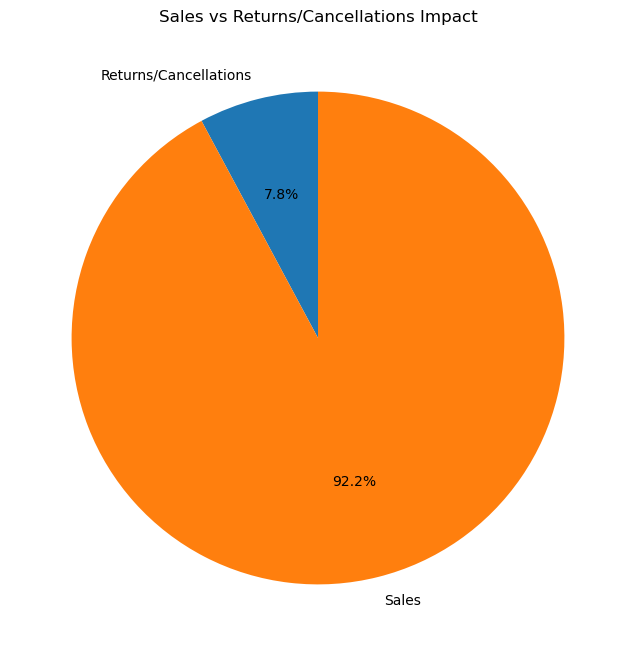

In [133]:
# Group by transaction type and use absolute values to show magnitude
# Returns/cancellations are negative, so abs() allows comparison as a positive impact amount
"""Since returns and cancellations create negative sales values, we used absolute values to display their magnitude in the pie chart. 
This allows us to compare the proportional impact of sales versus returns/cancellations."""
sales_returns_pie = (
    sales_returns_summary
    .groupby('Transaction_Type')['Total_Sales']
    .sum()
    .abs())

# Create a pie chart showing sales vs returns/cancellations impact
sales_returns_pie.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    figsize=(8, 8)
)

# Add chart title
plt.title('Sales vs Returns/Cancellations Impact')

# Remove default y-axis label for a cleaner pie chart
plt.ylabel('')

# Display the chart
plt.show()

Dashboard

In [134]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# =========================================================================
# 1. SETUP DATE HORIZONS & FILTER CONSTANTS
# =========================================================================
# Ensure your time dimensions are mapped to structured string attributes
df['Month_Str'] = df['YearMonth'].dt.strftime('%Y-%m')

# Extract unique target countries, sorted alphabetically
available_countries = sorted(df['Country'].unique())

# Pre-aggregate a Master Dictionary for lightning-fast dropdown switching
# This maps out both Month-level trend charts and Product-level bar charts
country_data = {}

for country in available_countries:
    country_sub = df[df['Country'] == country]

    # Trace 0 Data: Monthly Trend (Summing Quantity)
    trend = country_sub.groupby('Month_Str')['Quantity'].sum().reset_index()

    # Trace 1 Data: Top 10 Best Sellers (Summing Quantity, sorted ascending for horizontal bar)
    products = country_sub.groupby('Description')['Quantity'].sum().reset_index()
    products = products.sort_values(by='Quantity', ascending=False).head(10)
    products = products.sort_values(by='Quantity', ascending=True) # Ascending for correct horizontal display

    country_data[country] = {'trend': trend, 'products': products}

# Generate an absolute baseline aggregate (The "Global View")
global_trend = df.groupby('Month_Str')['Quantity'].sum().reset_index()
global_products = df.groupby('Description')['Quantity'].sum().reset_index()
global_products = global_products.sort_values(by='Quantity', ascending=False).head(10)
global_products = global_products.sort_values(by='Quantity', ascending=True)


# =========================================================================
# 2. CONSTRUCT THE COMPOSITE SUBPLOT GRID FRAMEWORK
# =========================================================================
fig = make_subplots(
    rows=2, cols=1,
    row_heights=[0.50, 0.50],
    subplot_titles=(
        "<b>1. Monthly Product Demand Trend (Total Volume Traded)</b>",
        "<b>2. Top 10 Best Selling Products (By Total Units Sold)</b>"
    ),
    vertical_spacing=0.15
)

# Initialize Trace Index 0: Chronological line chart (Global Baseline)
fig.add_trace(
    go.Scatter(
        x=global_trend['Month_Str'],
        y=global_trend['Quantity'],
        mode='lines+markers',
        name='Quantity Trend',
        line=dict(color='#008080', width=3), # Teal theme
        marker=dict(size=8),
        hovertemplate='<b>Month Horizon</b>: %{x}<br><b>Units Shipped</b>: %{y:,}<extra></extra>'
    ), row=1, col=1
)

# Initialize Trace Index 1: Best sellers horizontal bar chart (Global Baseline)
fig.add_trace(
    go.Bar(
        x=global_products['Quantity'],
        y=global_products['Description'],
        orientation='h',
        name='Product Volume',
        marker_color='#4682B4', # Steel blue theme
        hovertemplate='<b>Product Name</b>: %{y}<br><b>Units Shipped</b>: %{x:,}<extra></extra>'
    ), row=2, col=1
)


# =========================================================================
# 3. GENERATE DYNAMIC DROP-DOWN UPDATER ARRAYS
# =========================================================================
dropdown_buttons = []

# Option 1: Global Baseline Reset Configuration
dropdown_buttons.append(dict(
    method="update",
    label="🌍 Global Market (All Countries)",
    args=[{
        "x": [global_trend['Month_Str'], global_products['Quantity']],
        "y": [global_trend['Quantity'], global_products['Description']]
    }, {
        "title.text": "<b>Product Operations Matrix: Global Market (All Countries)</b>"
    }]
))

# Option 2 to Z: Dynamic country filtering loop
for country in available_countries:
    c_trend = country_data[country]['trend']
    c_products = country_data[country]['products']

    dropdown_buttons.append(dict(
        method="update",
        label=f"📍 {country}",
        args=[{
            # Target trace arrays sequentially: [Trace 0 parameter shifts, Trace 1 parameter shifts]
            "x": [c_trend['Month_Str'], c_products['Quantity']],
            "y": [c_trend['Quantity'], c_products['Description']]
        }, {
            # Update dashboard title header to show selected market
            "title.text": f"<b>Product Operations Matrix: Performance Tracking for {country}</b>"
        }]
    ))


# =========================================================================
# 4. DASHBOARD STYLING & INTERFACE DESIGN POLISHING
# =========================================================================
fig.update_layout(
    title={
        'text': "<b>Product Operations Matrix: Global Market (All Countries)</b>",
        'y': 0.96, 'x': 0.05, 'xanchor': 'left', 'yanchor': 'top',
        'font': dict(size=18)
    },
    template="plotly_white",
    height=850, # Generous height to keep product descriptions clear
    showlegend=False,

    # Embed the interactive control dropdown panel
    updatemenus=[dict(
        buttons=dropdown_buttons,
        direction="down",
        pad={"r": 10, "t": 10},
        showactive=True,
        x=0.05, xanchor="left",
        y=1.09, yanchor="top"
    )]
)

# Apply unified format commas down our structural numeric value lines
fig.update_yaxes(tickformat=",d", row=1, col=1)
fig.update_xaxes(tickformat=",d", row=2, col=1)

# Enforce clean visual margins so y-axis text blocks do not slide off canvas edges
fig.update_layout(margin=dict(l=250, r=50, t=120, b=50))

# Render dashboard view
fig.show()

In [135]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Missing_Description_Flag',
       'Cancelled_Order_Flag', 'CustomerID_Label', 'InvoiceDate_Day',
       'InvoiceDate_Time', 'InvoiceYear', 'InvoiceMonth', 'InvoiceDayName',
       'InvoiceHour', 'YearMonth', 'Invoice_Time_of_Day', 'Total_Sales',
       'Transaction_Type', 'Month_Str'],
      dtype='object')

In [136]:
df['Country'].value_counts()

Country
United Kingdom          487807
Germany                   9478
France                    8540
EIRE                      8180
Spain                     2527
Netherlands               2367
Belgium                   2069
Switzerland               1993
Portugal                  1510
Australia                 1255
Norway                    1085
Italy                      803
Channel Islands            757
Finland                    695
Cyprus                     611
Sweden                     461
Unspecified                442
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     294
USA                        291
Hong Kong                  284
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         57
